# 🛍️ Retail Customer Segmentation Analysis

### End-to-End Analysis: Revenue, Customer Behavior & Segmentation

**Author:** Kaushal Gaur  
**Tools:** Python | Pandas | NumPy | Matplotlib | SQL | Power BI  

---

This project analyzes an online retail dataset to understand customer purchasing behavior and identify high-value customer segments.

Using **RFM (Recency, Frequency, Monetary)** analysis, customers are segmented into groups such as **Champions, Loyal Customers, Potential Customers, and Lost Customers**.

The objective is to improve customer retention, increase revenue, and enable data-driven marketing strategies.

### 🔑 Key KPIs:
- Total Revenue  
- Customer Retention (Recency & Frequency)  
- Average Order Value (AOV)  
- Revenue Contribution by Segment  

# Business Objective

The objective of this project is to analyze customer purchasing behavior using transactional retail data and generate actionable business insights.

By applying RFM (Recency, Frequency, Monetary) analysis, customers are segmented into behavioral groups based on how recently they purchased, how often they purchase, and how much they spend.

This segmentation enables the identification of high-value customers, detection of at-risk or inactive customers, and a deeper understanding of purchasing patterns.

The ultimate goal is to support data-driven decision-making by improving customer retention, increasing customer lifetime value (CLTV), and driving revenue growth through targeted marketing strategies.

# Data Understanding

The dataset contains transactional data from an online retail store, where each row represents a single product purchased within a transaction.

Key fields include:

- Invoice number (transaction identifier)
- Product code and description
- Quantity purchased
- Invoice date (timestamp of purchase)
- Unit price of the product
- Customer ID (unique identifier for each customer)
- Country (customer location)

This dataset enables analysis of customer purchasing behavior, revenue patterns, and customer-level metrics required for RFM (Recency, Frequency, Monetary) segmentation.

### Load Dataset

In [1]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Dataset Overview

### Dataset Size

In [2]:
df.shape

(525461, 8)

### Column Names

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

### Missing Values

In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

### Observations

The dataset contains missing values mainly in the **Customer ID** and **Description** columns.

Since customer segmentation requires identifying unique customers, rows with missing **Customer ID** will be removed during the data cleaning stage.

### Detect Product Returns (Negative Quantity)

In this dataset, returned products are represented by **negative quantity values**.  
These records indicate that a product was returned by the customer after purchase.

Before performing further analysis, we identify these transactions so that we can decide whether to remove them or handle them appropriately during the data cleaning stage.

In [5]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [6]:
(df['Quantity']<0).sum()

np.int64(12326)

### 🔍 Observation:
- Approximately **12,326 transactions** have negative quantities, indicating product returns.
- These records should be handled carefully (removed or treated separately) during data cleaning to ensure accurate analysis.

### Data Cleaning

After identifying cancelled orders and product returns, we clean the dataset by removing transactions with negative quantities.

Negative quantities represent returned items or cancelled purchases.  
For customer behavior analysis, we keep only **valid purchase transactions** where the quantity is greater than zero.

In [7]:
df_clean = df[df['Quantity'] > 0].copy()

In [8]:
df_clean.shape

(513135, 8)

In [9]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


🔍 **Observation:**

- Transactions with negative quantities (returns/cancellations) have been removed from the dataset.
- Approximately **12,000+ records** were excluded to ensure only valid purchase transactions remain.
- The cleaned dataset now contains only **positive quantity transactions**, making it suitable for accurate customer behavior and revenue analysis.
- This step improves data quality and ensures reliable results in RFM segmentation.

### Create Revenue Column

In [10]:
df_clean.loc[:, 'Revenue'] = df_clean['Quantity'] * df_clean['Price']

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


🔍 **Observation:**

- A new **Revenue** column has been created by multiplying **Quantity × Price**.
- This represents the **total value of each transaction line item**.
- The dataset is now enriched with a key business metric required for revenue analysis and RFM segmentation.
- This column will be used for calculating total revenue, customer value, and segment-wise contribution.

### Customer-Level Feature Engineering

We created additional metrics to better understand customer behavior:

- Total Orders → purchase frequency
- Total Revenue → customer value
- AOV (Average Order Value) → spending behavior

These features help in deeper segmentation and marketing strategy.

In [11]:
customer_features = df_clean.groupby('Customer ID').agg({
    'Invoice': 'nunique',
    'Revenue': 'sum',
    'Quantity': 'sum'
}).rename(columns={
    'Invoice': 'Total_Orders',
    'Revenue': 'Total_Revenue',
    'Quantity': 'Total_Quantity'
})

customer_features['AOV'] = customer_features['Total_Revenue'] / customer_features['Total_Orders']

customer_features.head()

,Total_Orders,Total_Revenue,Total_Quantity,AOV
Customer ID,,,,
12346.0,11,372.86,70,33.896364
12347.0,2,1323.32,828,661.660000
12348.0,1,222.16,373,222.160000
12349.0,3,2671.14,993,890.380000
12351.0,1,300.93,261,300.930000


🔍 **Observation:**

- Customer-level features have been created by aggregating transactional data.
- **Total Orders** captures purchase frequency, **Total Revenue** reflects customer value, and **Total Quantity** indicates purchase volume.
- **AOV (Average Order Value)** provides insight into customer spending behavior per order.
- This transformation converts transactional data into **customer-centric metrics**, which are essential for RFM segmentation and strategic decision-making.

### Calculate Business KPIs

After cleaning the dataset and creating the Revenue column, we calculate some key business metrics (KPIs).

These metrics provide a high-level overview of the business performance and customer activity in the dataset.

The main KPIs we calculate are:

- Total Revenue generated
- Total number of unique orders
- Total number of unique customers

1. Total Revenue

In [12]:
round(df_clean['Revenue'].sum(),2)

np.float64(10169713.57)

2. Total Orders

In [13]:
df_clean['Invoice'].nunique()

22104

3. Total Customers

In [14]:
df_clean['Customer ID'].nunique()

4314

🔍 **Observation:**

- The business generated approximately **$10.17M in total revenue**, indicating strong overall sales performance.
- A total of **22,104 unique orders** were placed, reflecting active customer transactions.
- The dataset contains **4,314 unique customers**, showing a broad customer base.
- These KPIs provide a high-level view of business scale and will support deeper customer segmentation and performance analysis.

## Top 10 Best Selling Products

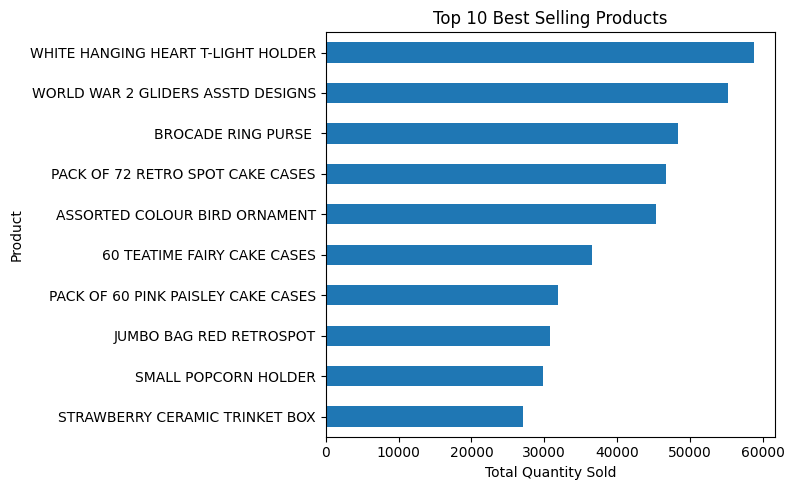

In [33]:
import matplotlib.pyplot as plt

top_products = (
    df_clean
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
top_products.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Top 10 Best Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

🔍 **Observation:**

- The top-selling product is **WHITE HANGING HEART T-LIGHT HOLDER**, indicating very high demand.
- A few products dominate sales volume, suggesting a **skewed distribution (Pareto effect)**.
- Items like decorative and gift products appear frequently, highlighting customer preference trends.
- These insights can help businesses focus on **inventory planning, promotions, and product bundling strategies**.

## Revenue by Country

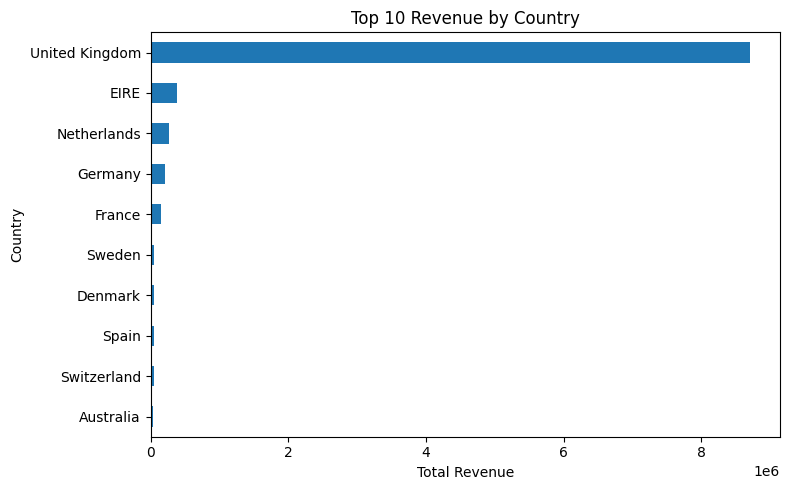

In [34]:
import matplotlib.pyplot as plt

revenue_country = (
    df_clean
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
revenue_country.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Top 10 Revenue by Country")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

🔍 **Observation:**

- The **United Kingdom dominates revenue contribution** by a huge margin compared to all other countries.
- Other countries contribute significantly less, indicating a **high geographic concentration of revenue**.
- Markets like **EIRE, Netherlands, and Germany** show potential but are still far behind the UK.
- This suggests an opportunity to **expand and optimize international markets** while maintaining strong performance in the UK.

### Sales Trends Over Time

To understand how business performance changes over time, we analyze monthly revenue trends.

By grouping transactions by month and summing the revenue, we can observe how sales increase or decrease across different months.

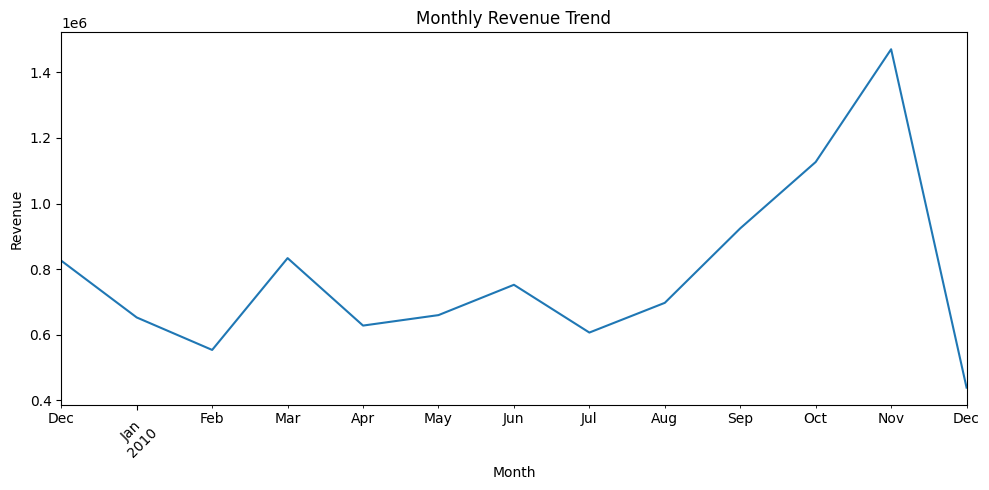

In [35]:
import matplotlib.pyplot as plt

df_clean.loc[:, 'InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean.loc[:, 'Month'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_revenue = df_clean.groupby('Month')['Revenue'].sum()

# Plot
monthly_revenue.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🔍 **Observation:**

- Revenue shows a **fluctuating trend across months**, indicating varying customer activity.
- There is a **strong upward trend from August to November**, with a peak in **November**, likely due to seasonal demand (e.g., holidays).
- A sharp drop in **December** suggests incomplete data or post-peak slowdown.
- These trends highlight **seasonality in sales**, which can help in planning inventory, marketing campaigns, and promotions.

### RFM Customer Segmentation

To better understand customer purchasing behavior, we apply **RFM analysis**.

RFM stands for:

- **Recency (R):** How recently a customer made a purchase
- **Frequency (F):** How often a customer makes purchases
- **Monetary (M):** How much money a customer spends

By calculating these three metrics for each customer, we can segment customers based on their purchasing behavior and identify valuable customer groups.

In [19]:
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate':'max',
    'Invoice':'nunique',
    'Revenue':'sum'
})
rfm.columns=['LastPurchaseDate','Frequency','Monetary']
rfm.head()

,LastPurchaseDate,Frequency,Monetary
Customer ID,,,
12346.0,2010-06-28 13:53:00,11,372.86
12347.0,2010-12-07 14:57:00,2,1323.32
12348.0,2010-09-27 14:59:00,1,222.16
12349.0,2010-10-28 08:23:00,3,2671.14
12351.0,2010-11-29 15:23:00,1,300.93


🔍 **Observation:**

- RFM metrics have been successfully created to capture **customer behavior dimensions**.
- **Recency** reflects the last purchase date, **Frequency** shows purchase count, and **Monetary** represents total spending.
- Customers now have a **structured behavioral profile**, enabling segmentation into high-value, loyal, and at-risk groups.
- This forms the foundation for **data-driven customer segmentation and targeted marketing strategies**.

### Calculate Recency

Recency measures how recently a customer made their last purchase.

To calculate recency, we first determine the **most recent transaction date in the dataset**.  
Then we calculate the number of days between that date and each customer's last purchase.

Customers with lower recency values have purchased more recently and are considered more engaged.

In [20]:
import datetime as dt
current_date=df_clean['InvoiceDate'].max()
rfm['Recency']=(current_date-rfm['LastPurchaseDate']).dt.days
rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency
Customer ID,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164
12347.0,2010-12-07 14:57:00,2,1323.32,2
12348.0,2010-09-27 14:59:00,1,222.16,73
12349.0,2010-10-28 08:23:00,3,2671.14,42
12351.0,2010-11-29 15:23:00,1,300.93,10


🔍 **Observation:**

- Recency values have been calculated as the number of days since each customer’s last purchase.
- Customers with **lower recency values are more recently active**, indicating higher engagement.
- Higher recency values indicate **inactive or at-risk customers** who haven’t purchased in a long time.
- This metric is crucial for identifying **loyal vs. churn-risk customers** in RFM segmentation.

### Assign RFM Scores

To categorize customers based on their RFM values, we convert the Recency, Frequency, and Monetary metrics into scores ranging from **1 to 5**.

This is done using **quantile-based binning**, where customers are divided into five groups based on their relative position in the dataset.

- **Recency Score (R):** Lower recency (recent purchases) receives a higher score.
- **Frequency Score (F):** Customers who purchase more frequently receive higher scores.
- **Monetary Score (M):** Customers who spend more money receive higher scores.

These scores help standardize customer behavior for segmentation analysis.

In [21]:
rfm['R_score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])

rfm['F_score']=pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score']=pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score
Customer ID,,,,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164,2,5,2
12347.0,2010-12-07 14:57:00,2,1323.32,2,5,2,4
12348.0,2010-09-27 14:59:00,1,222.16,73,2,1,1
12349.0,2010-10-28 08:23:00,3,2671.14,42,3,3,5
12351.0,2010-11-29 15:23:00,1,300.93,10,5,1,2


🔎 Observation:

- RFM scores (1–5) have been assigned using quantile-based segmentation.
- Customers with **higher R, F, M scores** represent the most valuable and engaged segments.
- This scoring system standardizes customer behavior, making it easier to identify patterns across the dataset.
- These scores will be used to create **customer segments (e.g., loyal, at-risk, champions)** in the next step.

### Combine RFM Scores

After calculating the individual R, F, and M scores, we combine them into a single **RFM score**.

This combined score represents the overall value of each customer based on their purchasing behavior.

In [22]:
rfm['RFM_Score']=(
    rfm['R_score'].astype(str)+
    rfm['F_score'].astype(str)+
    rfm['M_score'].astype(str)
)
rfm.head()


,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164,2,5,2,252
12347.0,2010-12-07 14:57:00,2,1323.32,2,5,2,4,524
12348.0,2010-09-27 14:59:00,1,222.16,73,2,1,1,211
12349.0,2010-10-28 08:23:00,3,2671.14,42,3,3,5,335
12351.0,2010-11-29 15:23:00,1,300.93,10,5,1,2,512


🔎 Observation:

- Individual R, F, and M scores have been successfully combined into a single **RFM Score**.
- This 3-digit score represents overall customer value and behavior in a compact form.
- Higher RFM scores (e.g., 555, 554) indicate **high-value and highly engaged customers**, while lower scores indicate less active or low-value customers.
- This combined score simplifies segmentation and will be used to group customers into meaningful business categories.

### Customer Segmentation

Using the RFM scores, customers are grouped into different segments based on their purchasing behavior.

These segments help businesses identify valuable customers, loyal customers, and customers who may need re-engagement.

In [36]:
# Convert RFM_Score to integer first
rfm['RFM_Score'] = rfm['RFM_Score'].astype(int)

def segment_rfm(score):
    if score >= 555:
        return 'Champions'
    elif score >= 445:
        return 'Loyal Customers'
    elif score >= 344:
        return 'Potential Customers'
    elif score >= 244:
        return 'Recent Customers'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_rfm)

rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,,
12346.0,2010-06-28 13:53:00,11,372.86,164,2,5,2,252,Recent Customers
12347.0,2010-12-07 14:57:00,2,1323.32,2,5,2,4,524,Loyal Customers
12348.0,2010-09-27 14:59:00,1,222.16,73,2,1,1,211,Lost Customers
12349.0,2010-10-28 08:23:00,3,2671.14,42,3,3,5,335,Recent Customers
12351.0,2010-11-29 15:23:00,1,300.93,10,5,1,2,512,Loyal Customers


🔎 Observation:

- Customers have been successfully segmented into meaningful groups based on their RFM scores.
- High-value segments like **Champions** and **Loyal Customers** represent the most engaged and profitable users.
- Segments like **Recent Customers** and **Potential Customers** offer opportunities for nurturing and upselling.
- **Lost Customers** highlight churn risk and require re-engagement strategies.
- This segmentation enables **targeted marketing, personalized campaigns, and better customer retention strategies**.

# Create Customer Segments Using RFM Scores

After calculating the RFM scores, customers are segmented into different groups based on their purchasing behavior.

The segmentation is based on Recency and Frequency scores:

Champions – Customers who purchased recently and buy frequently.
Loyal Customers – Customers who purchase frequently but may not have purchased recently.
Recent Customers – Customers who purchased recently but do not buy frequently yet.
Potential Customers – Customers with moderate engagement.
Lost Customers – Customers who have not purchased recently and buy rarely.

This segmentation helps businesses identify valuable customers and design targeted marketing strategies.

### Analyze Customer Segment Distribution

In [24]:
rfm['Segment'].value_counts()

Segment
Lost Customers         1519
Potential Customers     827
Loyal Customers         822
Recent Customers        796
Champions               350
Name: count, dtype: int64

### Revenue Contribution by Customer Segment

In [25]:
import matplotlib.pyplot as plt
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
total_revenue = segment_revenue.sum()

segment_pct = (segment_revenue / total_revenue * 100).round(2)

segment_analysis = pd.DataFrame({
    'Revenue': segment_revenue,
    'Contribution %': segment_pct
}).sort_values(by='Revenue', ascending=False)

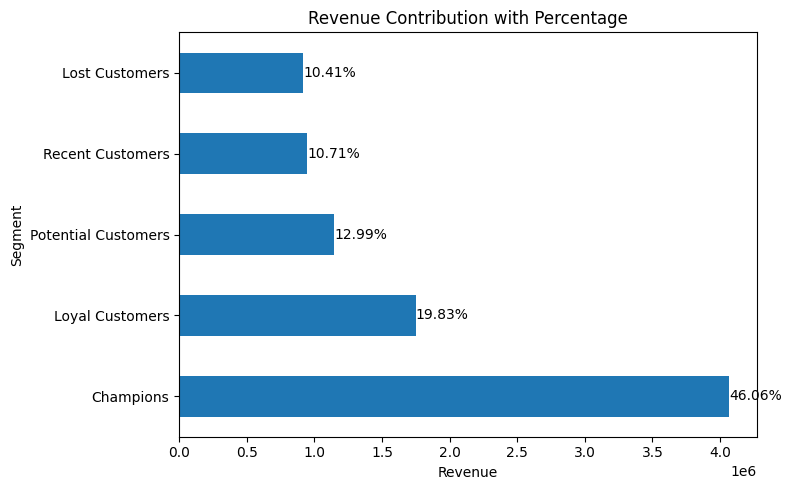

In [26]:
ax = segment_analysis['Revenue'].plot(kind='barh', figsize=(8,5))

for i, v in enumerate(segment_analysis['Revenue']):
    ax.text(v, i, f"{segment_analysis['Contribution %'].iloc[i]}%", va='center')

plt.title("Revenue Contribution with Percentage")
plt.xlabel("Revenue")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

### 📊 Insights: Revenue Contribution by Customer Segment

- **Champions** contribute the highest revenue (~46%), making them the most valuable customer group.
- **Loyal Customers** are the second biggest contributors (~20%), showing strong consistent purchasing behavior.
- **Potential and Recent Customers** contribute moderate revenue (~10–13%), indicating growth opportunities.
- **Lost Customers** still contribute some revenue (~10%), suggesting possible re-engagement strategies.

**Business Insight:** Focusing on retaining Champions and converting Potential Customers into Loyal ones can significantly boost overall revenue.

### Average Customer Value by Segment
We also calculate the average spending per customer in each segment. 
This helps identify which segments contain high-value customers.

In [37]:
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

Segment
Champions              11623.528323
Loyal Customers         2130.246343
Potential Customers     1387.594210
Recent Customers        1188.109964
Lost Customers           605.286323
Name: Monetary, dtype: float64

### Insights: Average Customer Value by Segment

- **Champions** have the highest average spending, confirming they are the most valuable customers.
- **Loyal Customers** also show strong average value, making them key for retention strategies.
- **Potential and Recent Customers** have moderate spending, indicating growth potential.
- **Lost Customers** have the lowest average value, reflecting low engagement and reduced business impact.

**Business Insight:** Focus on retaining Champions and upselling Loyal Customers, while nurturing Potential Customers to increase their value.

### Customer Segment Distribution

To understand how customers are distributed across different RFM segments, we visualize the number of customers in each segment.

This helps identify which customer groups are most common in the dataset and provides an overview of customer engagement levels.

Segments such as **Champions** and **Loyal Customers** represent highly engaged customers, while **Lost Customers** indicate customers who may require re-engagement strategies.

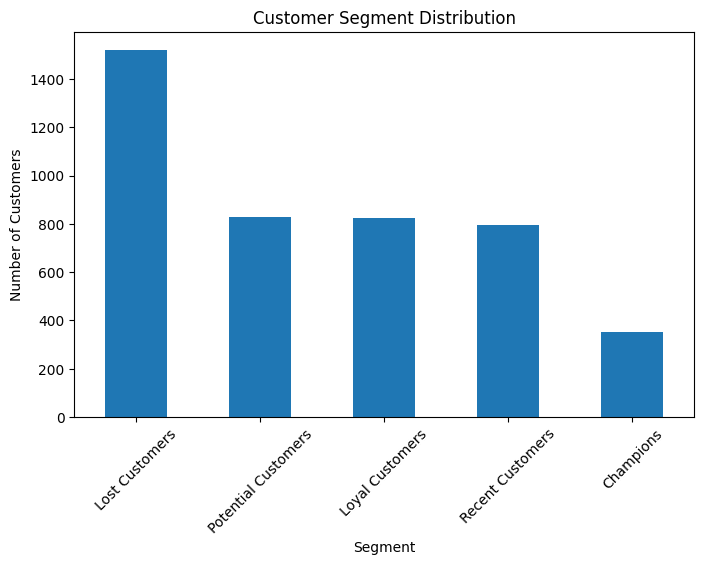

In [28]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(8,5))

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

### Revenue Contribution by Customer Segment

To better understand which customer groups drive the majority of revenue, we visualize the total revenue generated by each RFM segment.

This helps identify the most valuable customer groups and highlights where businesses should focus retention and engagement strategies.

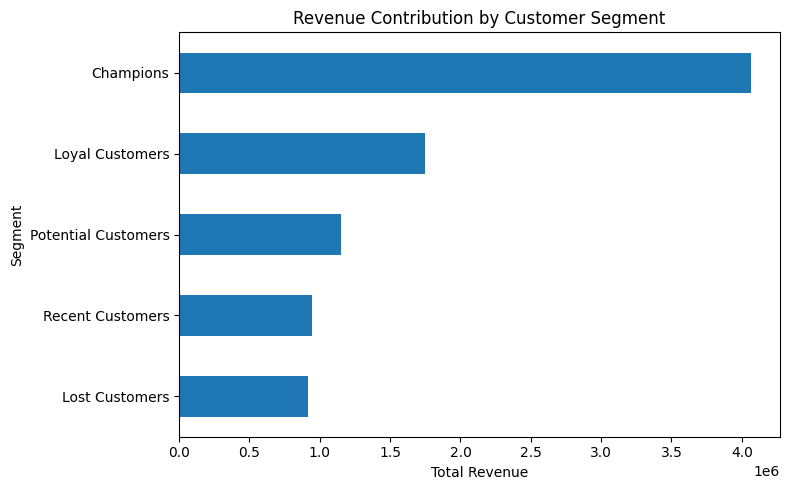

In [29]:
rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

### Revenue Contribution by Segment (Quantified)

This analysis shows the percentage contribution of each customer segment to total revenue.

Key Insight:
- A small group of customers (Champions) contributes the majority of revenue.
- This indicates a strong Pareto effect (80/20 rule).

In [30]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
total_revenue = segment_revenue.sum()

segment_pct = (segment_revenue / total_revenue * 100).round(2)
segment_analysis = pd.DataFrame({
    'Revenue': segment_revenue,
    'Contribution %': segment_pct
}).sort_values(by='Revenue', ascending=False)

segment_analysis

,Revenue,Contribution %
Segment,,
Champions,4068234.913,46.06
Loyal Customers,1751062.494,19.83
Potential Customers,1147540.412,12.99
Recent Customers,945735.531,10.71
Lost Customers,919429.924,10.41


🔎 Observation:

- **Champions contribute ~46% of total revenue**, confirming they are the most valuable segment.
- **Loyal Customers contribute ~20%**, showing consistent and reliable revenue generation.
- **Potential and Recent Customers (~10–13%)** represent strong growth opportunities.
- **Lost Customers still contribute ~10%**, indicating scope for re-engagement strategies.
- The distribution reflects a **Pareto-like pattern**, where a small segment drives a large portion of revenue.

## Key Business Insights

Based on the RFM segmentation analysis, several important insights emerge:

• **Champions** generate the highest total revenue and have the highest average spending. These customers are the most valuable and should be retained with loyalty programs and exclusive offers.

• **Loyal Customers** also contribute significant revenue. Businesses should focus on maintaining engagement with personalized promotions.

• **Potential Customers** represent a growth opportunity. Targeted marketing campaigns can help convert them into loyal customers.

• **Recent Customers** have purchased recently but not frequently yet. Encouraging repeat purchases through follow-up offers may increase their lifetime value.

• **Lost Customers** have low recency and frequency. Re-engagement campaigns or special discounts may help recover some of these customers.

## Business Impact & Recommendations

Based on the RFM analysis, we derive the following business impact:

- Champions contribute ~46% of total revenue → Retain with loyalty programs and exclusive offers
- Loyal Customers contribute ~20% → Upsell and cross-sell opportunities
- Potential Customers (~13%) → Convert using targeted campaigns
- Recent Customers (~10%) → Encourage repeat purchases with follow-ups
- Lost Customers (~10%) → Re-engage with discounts or remarketing

### Strategic Impact

- Top ~20% customers generate majority of revenue (Pareto Principle)
- Segment-based marketing can significantly improve retention and conversion
- Businesses can optimize marketing spend by focusing on high-value segments

## Final Summary

This project analyzed customer purchasing behavior using transactional retail data.

Key achievements:
- Cleaned and processed real-world messy data
- Performed RFM-based customer segmentation
- Identified high-value and at-risk customers
- Quantified revenue contribution by segment

Outcome:
This analysis enables data-driven marketing strategies to improve customer retention and maximize revenue.

## Conclusion

This project analyzed customer purchasing behavior using RFM (Recency, Frequency, Monetary) analysis on an online retail dataset.

Key steps included:

• Data cleaning and preparation  
• Revenue calculation and KPI analysis  
• Sales trend analysis  
• Customer segmentation using RFM scoring  
• Segment-wise revenue and customer value analysis  

The results show that a relatively small group of high-value customers (Champions and Loyal Customers) contributes a significant portion of total revenue.

These insights can help businesses design targeted marketing strategies, improve customer retention, and maximize overall revenue.

In [31]:
df_clean.to_csv("retail_clean.csv", index=False)

In [32]:
df_clean.to_csv("retail_powerbi_data.csv", index=False)